In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv('student_habits_performance.csv')

In [4]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [6]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [7]:
df["parental_education_level"].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', nan]
Length: 4, dtype: str

In [8]:
df["diet_quality"].unique()

<ArrowStringArray>
['Fair', 'Good', 'Poor']
Length: 3, dtype: str

In [9]:
df["internet_quality"].unique()

<ArrowStringArray>
['Average', 'Poor', 'Good']
Length: 3, dtype: str

In [10]:
df['parental_education_level']=df['parental_education_level'].fillna("Unknown")

In [11]:
df.isna().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [12]:
categorical_cols=["gender","part_time_job","diet_quality","parental_education_level","internet_quality","extracurricular_participation"]

In [13]:
for col in categorical_cols:
    print(f"Value count for {col}: \n{df[col].value_counts()}")

Value count for gender: 
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64
Value count for part_time_job: 
part_time_job
No     785
Yes    215
Name: count, dtype: int64
Value count for diet_quality: 
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64
Value count for parental_education_level: 
parental_education_level
High School    392
Bachelor       350
Master         167
Unknown         91
Name: count, dtype: int64
Value count for internet_quality: 
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64
Value count for extracurricular_participation: 
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64


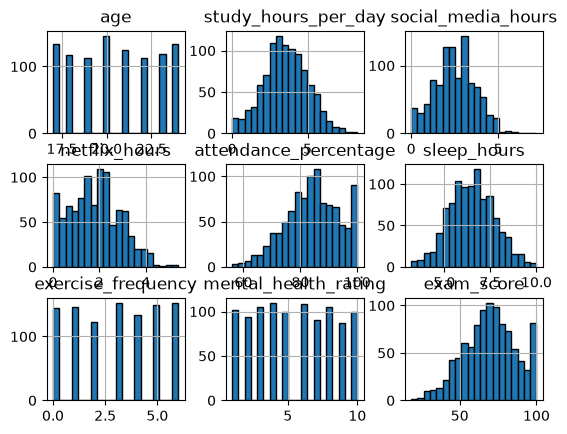

In [14]:
df.hist(bins=20,edgecolor="black")
plt.show()

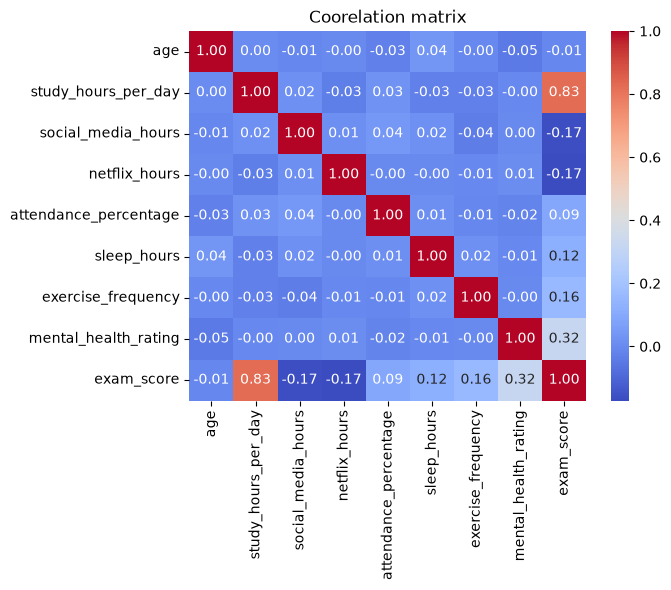

In [15]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Coorelation matrix")
plt.show()

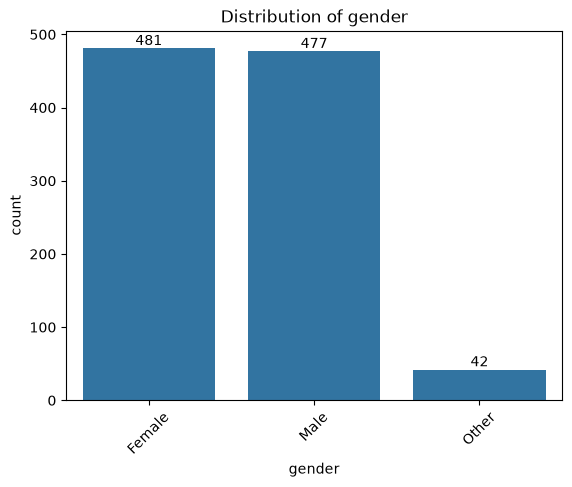

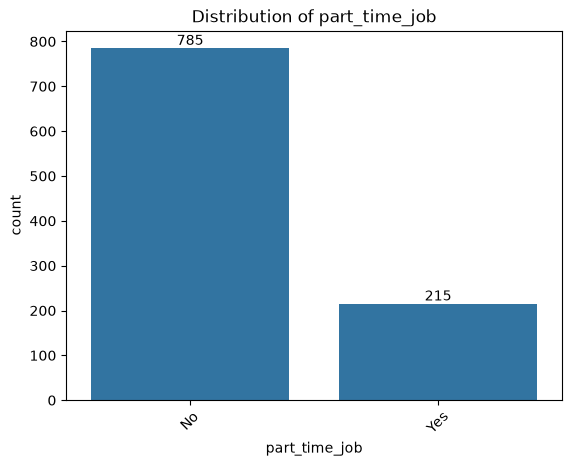

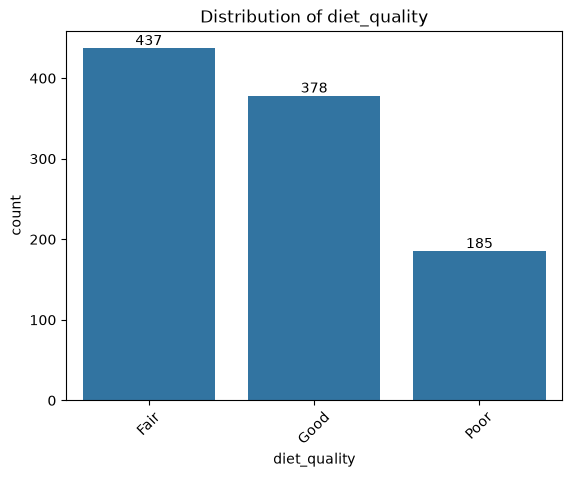

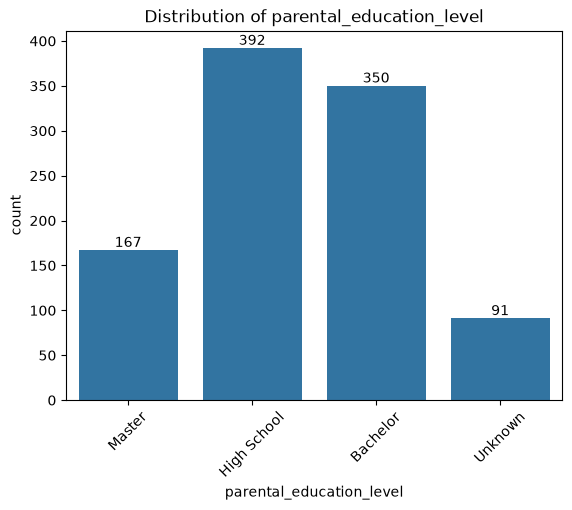

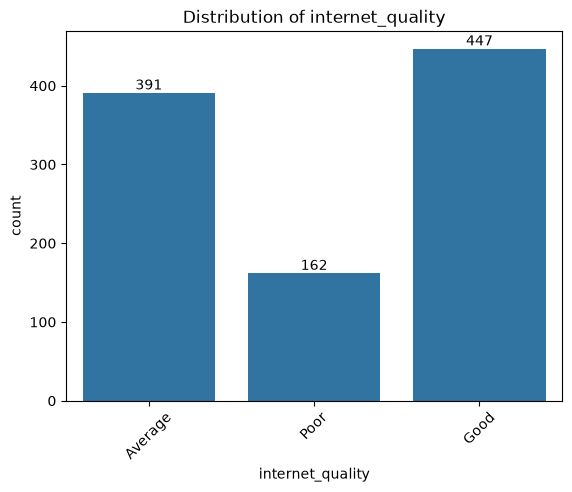

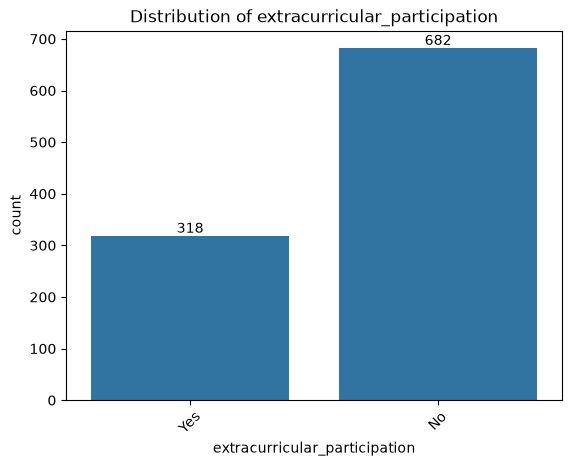

In [16]:
for col in categorical_cols:
    ax = sns.countplot(data=df, x=col)

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

    for container in ax.containers:
        ax.bar_label(container)

    plt.show()

In [17]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='str')

In [18]:
num_cols=['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

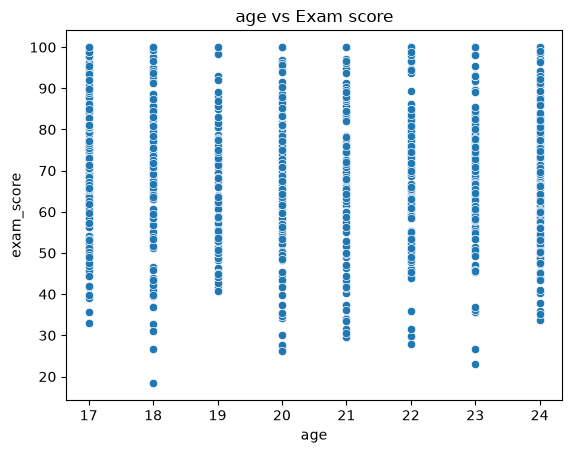

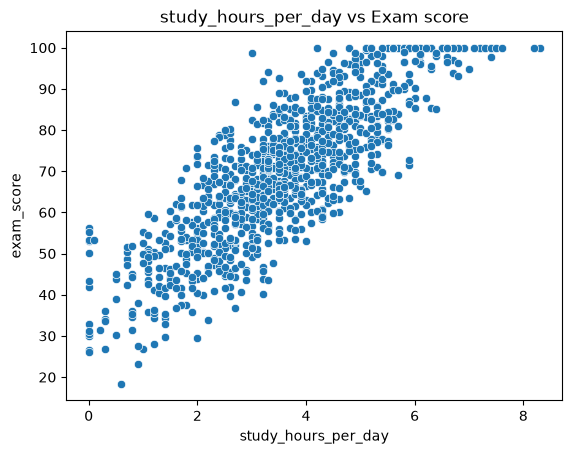

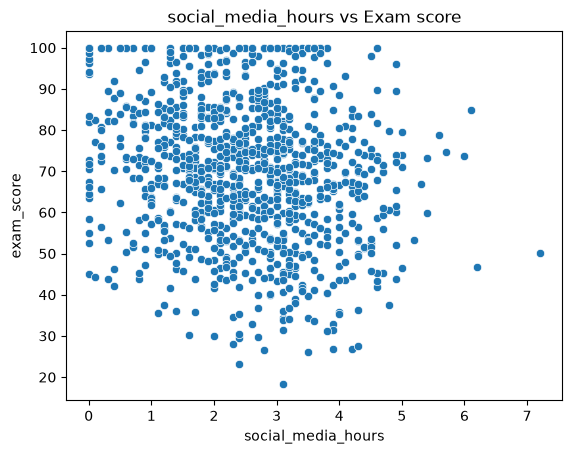

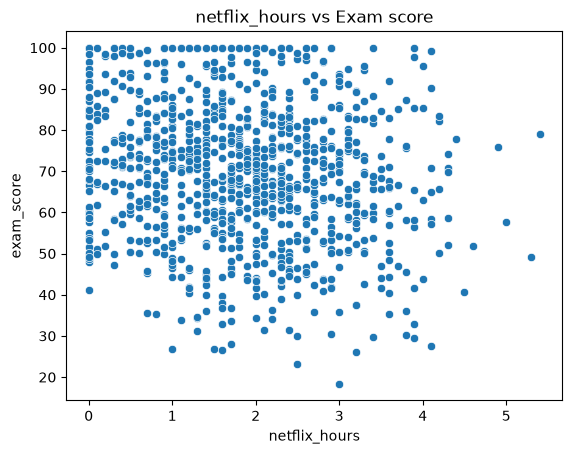

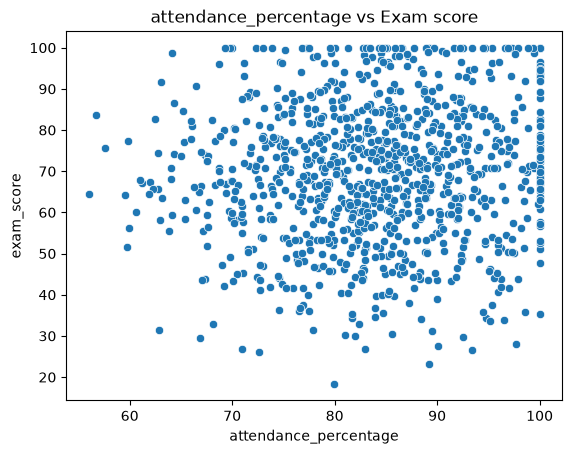

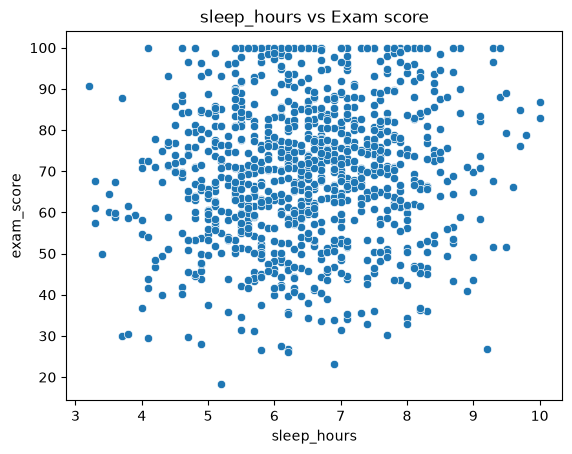

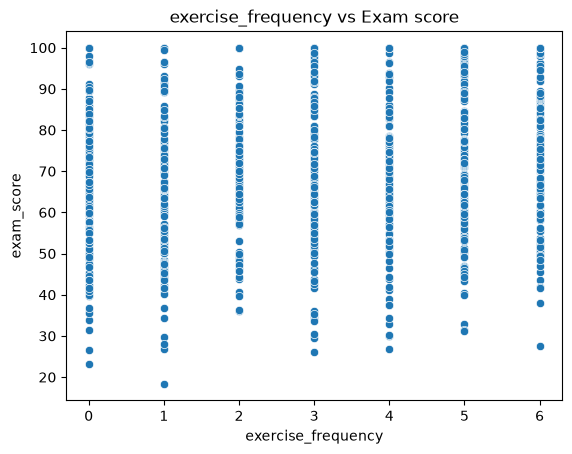

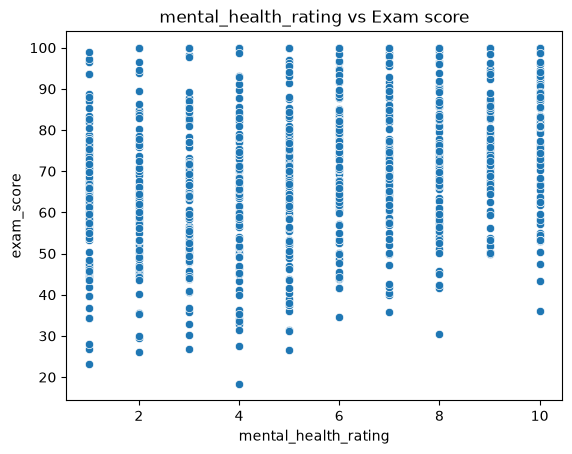

In [19]:
for f in num_cols:
    sns.scatterplot(data=df,x=f,y='exam_score')
    plt.title(f"{f} vs Exam score")
    plt.show()

 Model Trarining

In [20]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [21]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='str')

In [22]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [23]:
features=['study_hours_per_day',
          'attendance_percentage',
          'social_media_hours',
          'netflix_hours',
          'part_time_job',
          'sleep_hours',
          'extracurricular_participation']

In [24]:
target='exam_score'

In [25]:
df_model=df[features+[target]].copy()

In [26]:
df_model.head()

,study_hours_per_day,attendance_percentage,social_media_hours,netflix_hours,part_time_job,sleep_hours,extracurricular_participation,exam_score
0,0.0,85.0,1.2,1.1,No,8.0,Yes,56.2
1,6.9,97.3,2.8,2.3,No,4.6,No,100.0
2,1.4,94.8,3.1,1.3,No,8.0,No,34.3
3,1.0,71.0,3.9,1.0,No,9.2,Yes,26.8
4,5.0,90.9,4.4,0.5,No,4.9,No,66.4


In [27]:
le=LabelEncoder()

In [28]:
df_model["part_time_job"]=le.fit_transform(df_model["part_time_job"])

In [29]:
df_model["extracurricular_participation"]=le.fit_transform(df_model["extracurricular_participation"])

In [30]:
df_model.head()

,study_hours_per_day,attendance_percentage,social_media_hours,netflix_hours,part_time_job,sleep_hours,extracurricular_participation,exam_score
0,0.0,85.0,1.2,1.1,0,8.0,1,56.2
1,6.9,97.3,2.8,2.3,0,4.6,0,100.0
2,1.4,94.8,3.1,1.3,0,8.0,0,34.3
3,1.0,71.0,3.9,1.0,0,9.2,1,26.8
4,5.0,90.9,4.4,0.5,0,4.9,0,66.4


In [31]:
X=df_model[features]

In [32]:
y=df_model[target]

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20)

In [34]:
len(y_test)

200

In [35]:
len(y_train)

800

In [36]:
models={
    "LinearRegression":{
        "model":LinearRegression(),
        "params":{}
    },

    "DecisionTree":{
        "model":DecisionTreeRegressor(),
        "params":{"max_depth":[3,5,10],"min_samples_split":[2,5]}
    },
    "RandomForest":{
        "model":RandomForestRegressor(),
        "params":{"n_estimators":[50,100],
                  "max_depth":[5,10]}
    }
}

In [37]:
best_model=[]

In [38]:
for name,config in models.items():
    print(f"Training {name}")

    grid=GridSearchCV(config["model"],config["params"],cv=5,scoring="neg_mean_squared_error")
    grid.fit(X_train,y_train)

    y_pred=grid.predict(X_test)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    r2=r2_score(y_test,y_pred)

    best_model.append({
        "model":name,
        "best_params":grid.best_params_,
        "rmse":rmse,
        "r2":r2
    })

Training LinearRegression
Training DecisionTree
Training RandomForest


In [39]:
best_model

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': np.float64(7.667011955059711),
  'r2': 0.785314062563137},
 {'model': 'DecisionTree',
  'best_params': {'max_depth': 3, 'min_samples_split': 2},
  'rmse': np.float64(9.840835804276795),
  'r2': 0.6463161021904056},
 {'model': 'RandomForest',
  'best_params': {'max_depth': 5, 'n_estimators': 50},
  'rmse': np.float64(8.470773137323338),
  'r2': 0.7379420023510894}]

In [40]:
result_df=pd.DataFrame(best_model)

In [41]:
result_df.sort_values(by="rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},7.667012,0.785314
2,RandomForest,"{'max_depth': 5, 'n_estimators': 50}",8.470773,0.737942
1,DecisionTree,"{'max_depth': 3, 'min_samples_split': 2}",9.840836,0.646316


In [42]:
import joblib
best=result_df.sort_values(by="rmse").iloc[0]

In [43]:
best

model          LinearRegression
best_params                  {}
rmse                   7.667012
r2                     0.785314
Name: 0, dtype: object

In [44]:
best_model_name=best["model"]

In [45]:
best_model_config=models[best_model_name]
print(best_model_config)

{'model': LinearRegression(), 'params': {}}


In [46]:
final_model=best_model_config["model"]

In [47]:
final_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 9.51, 0.13,-2.7 ,..., 0.23, 2.02,-0.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['study_hours_per_day','attendance_percentage','social_media_hours',..., 'part_time_job','sleep_hours','extracurricular_participation']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [48]:
joblib.dump(final_model,f"{best_model_name}.pkl")

['LinearRegression.pkl']

Testing with Input values of dataset:

In [49]:
model = joblib.load("LinearRegression.pkl")

student = pd.DataFrame({
    "study_hours_per_day": [5],
    "attendance_percentage": [90],
    "social_media_hours": [2],
    "netflix_hours": [1],
    "part_time_job": [1],                   # encoded value
    "sleep_hours": [7],
    "extracurricular_participation": [1],   # encoded value
})

prediction = model.predict(student)

print("Predicted Exam Score:", prediction[0])

Predicted Exam Score: 88.5509277272525


In [50]:
#check yes or no
print(pd.crosstab(df["part_time_job"], df_model["part_time_job"]))

part_time_job    0    1
part_time_job          
No             785    0
Yes              0  215


In [51]:
#check yes or no
print(pd.crosstab(df["extracurricular_participation"], df_model["extracurricular_participation"]))

extracurricular_participation    0    1
extracurricular_participation          
No                             682    0
Yes                              0  318


In [52]:
X_test.iloc[[0]]
model.predict(X_test.iloc[[0]])

array([84.83114813])

In [53]:
print("Actual:", y_test.iloc[0])
print("Predicted:", model.predict(X_test.iloc[[0]])[0])

Actual: 98.7
Predicted: 84.83114812628844


In [54]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": model.predict(X_test)
})

comparison.head(50)

,Actual,Predicted
0,98.7,84.831148
1,78.0,78.198585
2,51.2,53.316210
3,58.9,57.873955
4,51.0,47.613131
5,52.6,52.056880
6,95.5,93.948754
7,83.0,79.664481
8,74.8,63.301302
9,72.2,73.383092


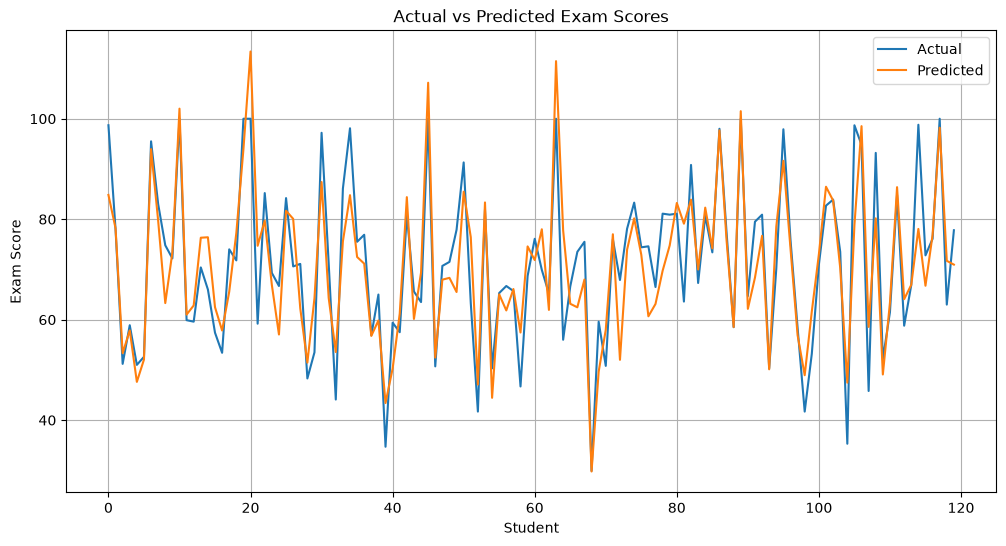

In [56]:
plt.figure(figsize=(12,6))

plt.plot(comparison["Actual"][:120], label="Actual")
plt.plot(comparison["Predicted"][:120], label="Predicted")

plt.title("Actual vs Predicted Exam Scores")
plt.xlabel("Student")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True)



plt.show()